# Exercise 03 - opening an online dataset

## NASA ocean color data 


This problem demonstrates how we can access Ocean Color data from NASA.


The main repository for NASAs ocean color data is: https://oceandata.sci.gsfc.nasa.gov/opendap/

We will look at data from the MODIS-Aqua (MODIS-A) satellite, and in particular we will look at the level 3 product, which is data that has gone through the highest level of processing and nicely gridded.


NASA organizes data by year and year day. You can see this structure by clicking through the OpenDAP server. The file used in this example contains the mapped chlorophyll-a data for July 28 (year day 210), 2019.



In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Use `xr.open_dataset()` to access the data

The data for yearday 210 of 2019 is located at:
```python
url = 'https://oceandata.sci.gsfc.nasa.gov:443/opendap/MODISA/L3SMI/2019/210/A2019210.L3m_DAY_CHL_chlor_a_4km.nc'
```


In [8]:
url = 'https://oceandata.sci.gsfc.nasa.gov/opendap/MODISA/L3SMI/2026/0210/AQUA_MODIS.20260210.L3m.DAY.CHL.chlor_a.4km.NRT.nc'
dataset = xr.open_dataset(url)

# Subset the data

let's just grab the mid-atlantic bight.

Note, that for some reason I don't understand, the `lat` `coords` are listed from high to low, so when you slice, you need to reverse the order, i.e. use `sel( lat=slice(41, 38))` *not* `sel( lat=slice( 38, 41)`. This is a mystery.

fill in the blanks to get a subset of the data that covers the MAB (the lat boundaries at 38 to 41 degrees, and lon boundaries are -76 to -71):

```python
data_mab_nj = data.___( lat = ___, lon = ___)
```

In [11]:
data_mab_nj = dataset.sel(lat=slice(41, 38), lon=slice(-76, -71))

# plot the chlorophyll a

for the mid atlantic bight subset using the built-in xarray plotting routine. i.e. fill in the blanks, and remember we want to just plot the variable `chlor_a`:
```python
data_mab_nj.___.___()
```



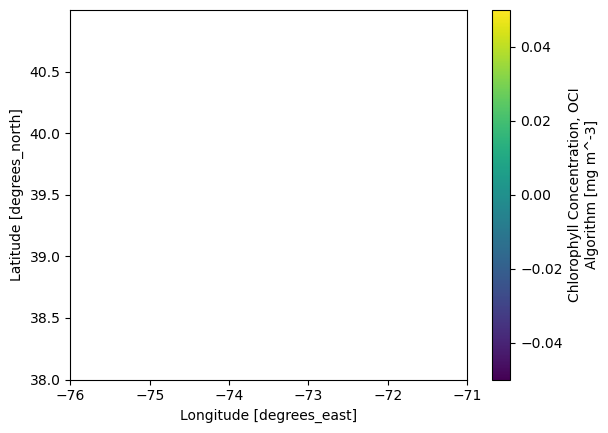

In [12]:
data_mab_nj.chlor_a.plot()

# Chla should be plotted on a log scale

Let's make the same plot with matplotlib, and use `np.log10()` to plot the data on a log scale:

```python
plt.pcolormesh( data_mab_nj.___, data_mab_nj.___, np.log10(data_mab_nj.___))
# add a colorbar


```
be sure to label all your axes

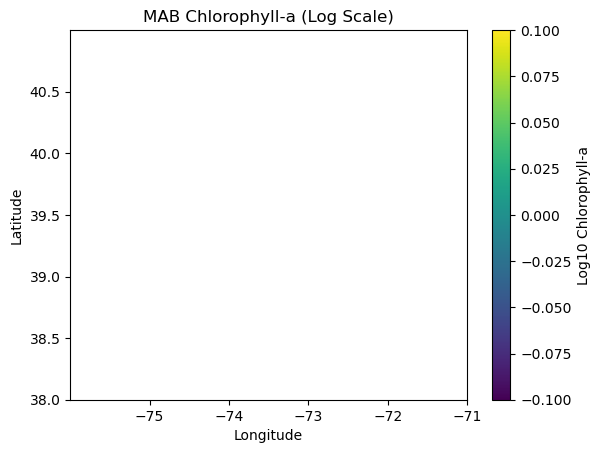

In [ ]:
plt.pcolormesh(data_mab_nj.lon, data_mab_nj.lat, np.log10(data_mab_nj.chlor_a))

plt.colorbar(label='Log10 Chlorophyll-a')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('MAB Chlorophyll-a (Log Scale)')
plt.show()

# BONUS!

Load and explore SPEAR_Med data for precip using the AWS hosted data and the AWS S3 bucket URL!

Link to AWS Collection: https://noaa-gfdl-spear-large-ensembles-pds.s3.amazonaws.com/index.html#SPEAR/GFDL-LARGE-ENSEMBLES/CMIP/NOAA-GFDL/GFDL-SPEAR-MED/

Example of a bucket url for interacting with the NC files: url = "s3://noaa-gfdl-spear-large-ensembles-pds/SPEAR/GFDL-LARGE-ENSEMBLES/CMIP/NOAA-GFDL/GFDL-SPEAR-MED/historical/r10i1p1f1/6hr/pr/gr3/v20210201/pr_6hr_GFDL-SPEAR-MED_historical_r10i1p1f1_gr3_192101010300-193012312100.nc"

In [14]:
# conda install s3fs
import s3fs

In [6]:
ds = xr.open_dataset(
    "s3://noaa-gfdl-spear-large-ensembles-pds/SPEAR/GFDL-LARGE-ENSEMBLES/CMIP/NOAA-GFDL/GFDL-SPEAR-MED/historical/r10i1p1f1/6hr/pr/gr3/v20210201/pr_6hr_GFDL-SPEAR-MED_historical_r10i1p1f1_gr3_192101010300-193012312100.nc",
    engine="h5netcdf",
    storage_options={"anon": True}
)

In [7]:
ds

<xarray.Dataset> Size: 12GB
Dimensions:    (time: 14608, bnds: 2, lat: 360, lon: 576)
Coordinates:
  * time       (time) object 117kB 1921-01-01 03:00:00 ... 1930-12-31 21:00:00
  * lat        (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon        (lon) float64 5kB 0.3125 0.9375 1.562 2.188 ... 358.4 359.1 359.7
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 234kB ...
    lat_bnds   (lat, bnds) float64 6kB ...
    lon_bnds   (lon, bnds) float64 9kB ...
    pr         (time, lat, lon) float32 12GB ...
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            SPEAR
    branch_method:          Initial conditions for this ensemble member were ...
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    contact:                gfdl.climate.model.info@noaa.gov
    ...                     ...
    variable_id:            pr
    variant_label:          r10i1p1f1
    cmor_version:           3.13.0
    parent_experiment_id:   none
    title:                  GFDL-SPEAR-MED output prepared for FLP
    license:                CC0-1.0